# Обучение модели прогноза погоды в Краснодарском крае

#### Мы будет обучать модель машинного обучения для предсказания следующих показателей precipitation (осадки), temp(средняя температура), tmax(максимальная тепелратура), tmin(минимальная температура), solar_radiation(солнечная радиация), wind_speed(скорость вертра), wind_direction(направление ветра), day_length_hours(длина световго дня) из датасэта, который подготовили в прошлом этапе. Предсказания будут стояться на основе анных координат районов(точек) и даты.

## 1. Импорт библиотек

 - `pandas`, `numpy` — работа с таблицами и массивами;
 - `matplotlib`, `seaborn` — визуализация графиков;
 - `sklearn` — весь ML-стек: препроцессинг (ColumnTransformer, Pipeline, SimpleImputer, StandardScaler, OneHotEncoder), модель (ExtraTreesRegressor), метрики (MAE, RMSE, R²), подбор параметров (RandomizedSearchCV);
 - `joblib` — сохранение обученной модели на диск;
 - `warnings`, `datetime` — подавление предупреждений и форматирование временных меток.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import joblib
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 2. Конфигурация

***Назначение***: собрать все настраиваемые параметры проекта в одном месте, чтобы менять их только здесь, а не искать по всему коду.

***Что содержит***:

 - `DATA_PATH` — путь к CSV-файлу с данными;
 - `TARGET_VARIABLES` — список из 8 целевых переменных, которые модель будет предсказывать: precipitation (осадки), temp(средняя температура), tmax(максимальная тепелратура), tmin(минимальная температура), solar_radiation(солнечная радиация), wind_speed(скорость вертра), wind_direction(направление ветра), day_length_hours(длина световго дня);
 - `NUMERIC_FEATURES` — числовые признаки для обучения: lat(широта), lon(долгота), month(месяц), day(день), dayofyear(день в году);
 - `CATEGORICAL_FEATURES` — категориальные признаки: sea_border, mountain_border, admin_center;
 - `ET_PARAMS` — гиперпараметры для разведочной модели (30 деревьев, глубина 20);
 - `IMPORTANCE_THRESHOLD` — порог важности признака (0.001), ниже которого признак считается бесполезным;
 - `TRAIN_YEARS`, `VAL_YEARS`, `TEST_YEARS` — хронологическое разделение: TRAIN 2018–2023, VAL 2024, TEST 2025.

In [6]:

DATA_PATH = 'data/data.csv'
RANDOM_STATE = 42

# Целевые переменные (Y)
TARGET_VARIABLES = [
    'precipitation', 'temp', 'tmax', 'tmin',
    'solar_radiation', 'wind_speed', 'wind_direction', 'day_length_hours'
]

# Признаки (X) — числовые
NUMERIC_FEATURES = [
    'lat', 'lon', 'month', 'day', 'dayofyear'
]

# Признаки (X) — категориальные
CATEGORICAL_FEATURES = [
    'sea_border', 'mountain_border', 'admin_center'
]

# ExtraTrees гиперпараметры (используются для первой разведочной модели)
ET_PARAMS = {
    'n_estimators': 30,
    'max_depth': 20,
    'min_samples_split': 10,
    'min_samples_leaf': 5,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': 0
}

# Пороги для фильтрации признаков
IMPORTANCE_THRESHOLD = 0.001

# РАЗДЕЛЕНИЕ ПО ГОДАМ
TRAIN_YEARS = [2018, 2019, 2020, 2021, 2022, 2023]
VAL_YEARS   = [2024]
TEST_YEARS  = [2025]



print(f"Целевые переменные: {TARGET_VARIABLES}")
print(f"Числовые признаки: {NUMERIC_FEATURES}")
print(f"Категориальные признаки: {CATEGORICAL_FEATURES}")
print(f"РАЗДЕЛЕНИЕ ПО ГОДАМ:")
print(f"   TRAIN: {TRAIN_YEARS}")
print(f"   VAL:   {VAL_YEARS}")
print(f"   TEST:  {TEST_YEARS}")


Целевые переменные: ['precipitation', 'temp', 'tmax', 'tmin', 'solar_radiation', 'wind_speed', 'wind_direction', 'day_length_hours']
Числовые признаки: ['lat', 'lon', 'month', 'day', 'dayofyear']
Категориальные признаки: ['sea_border', 'mountain_border', 'admin_center']
РАЗДЕЛЕНИЕ ПО ГОДАМ:
   TRAIN: [2018, 2019, 2020, 2021, 2022, 2023]
   VAL:   [2024]
   TEST:  [2025]


# 3. Загрузка и обработка данных

***Назначение***: загрузить датасет из CSV и подготовить все временны́е признаки.
Что происходит:

 - `pd.read_csv(DATA_PATH)` — загружает таблицу в DataFrame data;
 - `pd.to_datetime(data['date'], errors='coerce')` — парсит строки дат в объект datetime, невалидные значения превращает в NaT;
 - из даты извлекаются столбцы: `year`, `month`, `day`, `dayofyear` — все они будут нужны либо как признаки, либо для разбивки по годам;


In [7]:
data = pd.read_csv(DATA_PATH)
data['date']      = pd.to_datetime(data['date'], errors='coerce')
data['year']      = data['date'].dt.year
data['month']     = data['date'].dt.month
data['day']       = data['date'].dt.day
data['dayofyear'] = data['date'].dt.dayofyear
display(data.head())

,date,lat,lon,precipitation,temp,tmax,tmin,solar_radiation,wind_speed,wind_direction,geometry,day_length_hours,admin_center,sea_border,mountain_border,year,month,day,dayofyear
0,1995-01-01,44.6,38.3,18.158067,6.350861,7.273407,5.483612,1114473.80,5.725473,183.35031,POINT (38.3 44.6),8.63,Абинск,No sea,1,1995,1,1,1
1,1995-01-01,44.6,38.4,18.483881,6.168884,7.058563,5.409393,1065007.00,5.916834,183.78326,POINT (38.4 44.6),8.63,Абинск,No sea,1,1995,1,1,1
2,1995-01-01,44.7,38.0,14.895755,7.149780,8.113800,5.770721,2020211.95,6.080730,186.59811,POINT (38 44.7),8.63,Абинск,No sea,1,1995,1,1,1
3,1995-01-01,44.7,38.1,14.656830,6.913940,7.912079,5.594940,1549324.10,5.823010,186.85516,POINT (38.1 44.7),8.63,Абинск,No sea,1,1995,1,1,1
4,1995-01-01,44.7,38.2,14.466914,6.832459,7.958954,5.551971,1377085.45,5.663302,187.66335,POINT (38.2 44.7),8.63,Абинск,No sea,1,1995,1,1,1


# 4. Анализ категориальных признаков

***Назначение***: изучить уникальные значения категориальных признаков, чтобы понять их мощность (количество категорий) перед кодированием.

Что выводится для каждого признака (`sea_border`, `mountain_border`, `admin_center`):
- количество уникальных значений (важно для понимания размерности после OHE);
первые 5 примеров значений.


***Зачем это нужно***: если у категориального признака очень много уникальных значений (например, 44 у admin_center), это означает, что после OneHotEncoder появится 44 новых бинарных столбца — это влияет на скорость обучения и интерпретацию важности признаков.

In [8]:
for cat_feature in CATEGORICAL_FEATURES:
    n_unique = data[cat_feature].nunique()
    print(f"{cat_feature}:")
    print(f"  • Уникальные значения: {n_unique}")
    print(f"  • Примеры: {data[cat_feature].unique()[:5].tolist()}")

sea_border:
  • Уникальные значения: 4
  • Примеры: ['No sea', 'Azov Sea', 'Black Sea and Azov Sea', 'Black Sea']
mountain_border:
  • Уникальные значения: 2
  • Примеры: [1, 0]
admin_center:
  • Уникальные значения: 44
  • Примеры: ['Абинск', 'Апшеронск', 'Белая Глина', 'Белореченск', 'Брюховецкая']


# 5. Формирование матрицы признаков и целевых пременных

***Назначение***: разделить общий датасет на матрицу признаков X и матрицу целевых переменных y.

***Что создаётся***:

 - `y = data[TARGET_VARIABLES]` — DataFrame с 8 столбцами целевых переменных (multi-output regression);
 - `X = data[NUMERIC_FEATURES + CATEGORICAL_FEATURES]` — DataFrame с 8 признаками: 5 числовых + 3 категориальных.


***Важно***: X и y делаются через .copy(), чтобы последующие операции над ними не изменяли исходный data. Оба объекта сохраняют оригинальный индекс data — это принципиально важно для корректного разделения по годам в следующем этапе.

***Вывод***: формы X и y, списки признаков и таргетов.

In [9]:
y = data[TARGET_VARIABLES].copy()
X = data[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()

print(f"Целевые переменные (Y): {len(TARGET_VARIABLES)} переменных")
print(f"{TARGET_VARIABLES}")
print(f"Признаки (X): {X.shape[1]} признаков")
print(f"Числовые ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Категориальные ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"X shape: {X.shape}, Y shape: {y.shape}")


Целевые переменные (Y): 8 переменных
['precipitation', 'temp', 'tmax', 'tmin', 'solar_radiation', 'wind_speed', 'wind_direction', 'day_length_hours']
Признаки (X): 8 признаков
Числовые (5): ['lat', 'lon', 'month', 'day', 'dayofyear']
Категориальные (3): ['sea_border', 'mountain_border', 'admin_center']
X shape: (9309439, 8), Y shape: (9309439, 8)



# 6. Разделение данных по годам

***Назначение***: разбить данные на три хронологических непересекающихся выборки: TRAIN, VAL, TEST.

***Как работает***:

 - `data.sort_values('date')` — сортируем data по дате без reset_index, чтобы индексы data, X и y оставались согласованными;
 - строятся булевы маски: `train_mask = data['year'].isin(TRAIN_YEARS)` и аналогично для VAL и TEST;
 - маски применяются к X и y через булево индексирование X[train_mask] — это даёт правильный срез.


***Почему хронологическое разделение, а не random_split***: данные о погоде имеют временну́ю зависимость. Случайное перемешивание приводит к утечке данных из будущего в прошлое — модель будет знать о завтрашней погоде при обучении на вчерашней.

***Что создаётся***: X_train, y_train, X_val, y_val, X_test, y_test.

In [10]:
data = data.sort_values('date')

print(f"TRAIN годы: {TRAIN_YEARS}")
print(f"VAL годы:   {VAL_YEARS}")
print(f"TEST годы:  {TEST_YEARS}")

# Булевы маски по оригинальному индексу
train_mask = data['year'].isin(TRAIN_YEARS)
val_mask   = data['year'].isin(VAL_YEARS)
test_mask  = data['year'].isin(TEST_YEARS)

# X и y используют тот же индекс что и data — срез корректен
X_train = X[train_mask].copy()
y_train = y[train_mask].copy()

X_val = X[val_mask].copy()
y_val = y[val_mask].copy()

X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

print(
    f"TRAIN: {X_train.shape[0]} строк "
    f"({data[train_mask]['date'].min().date()} - {data[train_mask]['date'].max().date()})"
)
print(
    f"VAL:   {X_val.shape[0]} строк "
    f"({data[val_mask]['date'].min().date()} - {data[val_mask]['date'].max().date()})"
)
print(
    f"TEST:  {X_test.shape[0]} строк "
    f"({data[test_mask]['date'].min().date()} - {data[test_mask]['date'].max().date()})"
)

TRAIN годы: [2018, 2019, 2020, 2021, 2022, 2023]
VAL годы:   [2024]
TEST годы:  [2025]
TRAIN: 1794260 строк (2018-01-01 - 2023-12-31)
VAL:   299716 строк (2024-01-01 - 2024-12-31)
TEST:  293313 строк (2025-01-01 - 2025-12-24)


# 7. Создание Preprocessor

***Назначение***: собрать объект preprocessor, который автоматически обрабатывает числовые и категориальные признаки перед подачей в модель.

***Из чего состоит***:

 - `numeric_transformer` — Pipeline из двух шагов:
 - `SimpleImputer(strategy='median')` — заполняет пропуски медианой столбца;
 - `StandardScaler()` — нормализует признаки к нулевому среднему и единичной дисперсии (нужно для корректной работы скейлинга, хотя ExtraTrees нечувствителен к масштабу — это хорошая практика).
 - `categorical_transformer` — Pipeline из двух шагов:
 - `SimpleImputer(strategy='most_frequent')` — заполняет пропуски наиболее частой категорией;
 - `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` — кодирует категории в бинарные столбцы; handle_unknown='ignore' означает, что неизвестные категории в TEST (которых не было в TRAIN) будут кодироваться нулями.
 - `ColumnTransformer` — объединяет оба трансформера и применяет каждый к своим столбцам.

In [11]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Категориальный трансформер
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ]
)

# 8. Вспомогательные функции

***Назначение***: определить три многократно используемые функции для оценки и визуализации результатов.

`print_metrics_per_target(y_true, y_pred, target_names, model_name): `
 - принимает истинные и предсказанные значения в виде numpy-массивов;
 - для каждого из 8 таргетов считает MAE, RMSE, R²;
 - добавляет колонку Качество: ✅ если R² > 0.5, ⚠️ если 0 < R² ≤ 0.5, ❌ если R² < 0;
 - выводит таблицу и итоговые средние значения;
 - возвращает metrics_df для дальнейшего использования.


`analyze_feature_importance(model, feature_names_list, top_n, verbose)`:
 - извлекает feature_importances_ из model.named_steps['model'];
 - строит DataFrame с именами признаков и их важностью, отсортированный по убыванию;
 - выводит топ-N признаков и статистику по трём уровням важности (высокая / средняя / низкая).


`plot_feature_importance(importance_df, top_n, save_path):`
 - строит горизонтальную барчарт с цветовым кодированием по уровням важности;
 - сохраняет график в PNG-файл.

In [ ]:
def print_metrics_per_target(y_true, y_pred, target_names, model_name=""):
    metrics_list = []
    for i, target in enumerate(target_names):
        mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
        rmse = mean_squared_error(y_true[:, i],  y_pred[:, i]) ** 0.5
        r2   = r2_score(y_true[:, i], y_pred[:, i])
        metrics_list.append({
            'Target':    target,
            'MAE':       mae,
            'RMSE':      rmse,
            'R²':        r2,
            'Качество':  '✅ Хорошо' if r2 > 0.5 else ('⚠️  Среднее' if r2 > 0 else '❌ Плохо')
        })

    metrics_df = pd.DataFrame(metrics_list)
    print(f"\n{'='*90}")
    print(f"МЕТРИКИ: {model_name}")
    print(f"{'='*90}")
    display(metrics_df)
    print(f"\n{'ИТОГОВЫЕ СТАТИСТИКИ':^90}")
    print(f"  MAE (среднее):  {metrics_df['MAE'].mean():.4f} ± {metrics_df['MAE'].std():.4f}")
    print(f"  RMSE (среднее): {metrics_df['RMSE'].mean():.4f} ± {metrics_df['RMSE'].std():.4f}")
    print(f"  R² (среднее):   {metrics_df['R²'].mean():.4f} ± {metrics_df['R²'].std():.4f}")
    print(f"{'='*90}\n")
    return metrics_df


def analyze_feature_importance(model, feature_names_list, top_n=30, verbose=True):
    """Анализирует и выводит важность признаков из обученной модели."""
    feature_importance = model.named_steps['model'].feature_importances_

    importance_df = pd.DataFrame({
        'Feature':    feature_names_list,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)

    if verbose:
        print(f"\n{'='*90}")
        print(f"АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ (TOP {top_n})")
        print(f"{'='*90}")
        display(importance_df.head(top_n))

        total    = len(importance_df)
        high_imp = len(importance_df[importance_df['Importance'] > 0.01])
        mid_imp  = len(importance_df[(importance_df['Importance'] > 0.001) & (importance_df['Importance'] <= 0.01)])
        low_imp  = len(importance_df[importance_df['Importance'] <= 0.001])

        print(f"\n{'СТАТИСТИКА ВАЖНОСТИ':^90}")
        print(f"  🟢 Высокая (> 0.01):       {high_imp} признаков ({high_imp/total*100:.1f}%)")
        print(f"  🟡 Средняя (0.001-0.01):  {mid_imp} признаков ({mid_imp/total*100:.1f}%)")
        print(f"  🔴 Низкая (≤ 0.001):       {low_imp} признаков ({low_imp/total*100:.1f}%)")
        print(f"{'='*90}\n")

    return importance_df


def plot_feature_importance(importance_df, top_n=30):
    """Визуализирует важность признаков."""
    fig, ax = plt.subplots(figsize=(14, 10))
    top_df = importance_df.head(top_n).copy()

    colors = [
        '#2ecc71' if x > 0.01 else ('#f39c12' if x > 0.001 else '#e74c3c')
        for x in top_df['Importance']
    ]

    ax.barh(range(len(top_df)), top_df['Importance'], color=colors)
    ax.set_yticks(range(len(top_df)))
    ax.set_yticklabels(top_df['Feature'], fontsize=10)
    ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
    ax.set_title(f'Top-{top_n} Feature Importance для ExtraTrees',
                 fontsize=14, fontweight='bold', pad=20)
    ax.invert_yaxis()

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='Высокая (> 0.01)'),
        Patch(facecolor='#f39c12', label='Средняя (0.001-0.01)'),
        Patch(facecolor='#e74c3c', label='Низкая (≤ 0.001)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

    for i, (_, row) in enumerate(top_df.iterrows()):
        ax.text(row['Importance'], i, f" {row['Importance']:.4f}",va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
    return fig


# 9. Обучение разведочной модели

***Назначение:*** обучить быструю предварительную модель на TRAIN-выборке, чтобы оценить качество признаков и получить базовые метрики — до подбора гиперпараметров.

***Что создаётся:***
`et_model_v1` — Pipeline из двух шагов: `preprocessor` + `ExtraTreesRegressor(**Config.ET_PARAMS)`;
параметры разведочной модели намеренно облегчённые: всего 30 деревьев, чтобы обучение не занимало много времени.

***Вывод:*** список параметров модели и сообщение об успешном обучении.


In [13]:
for key, value in ET_PARAMS.items():
    print(f"  • {key}: {value}")

et_model_v1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ExtraTreesRegressor(**ET_PARAMS))
])

et_model_v1.fit(X_train, y_train)

  • n_estimators: 30
  • max_depth: 20
  • min_samples_split: 10
  • min_samples_leaf: 5
  • random_state: 42
  • n_jobs: -1
  • verbose: 0


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# 10. Предсказание и метрики на VAL

***Назначение:*** оценить качество разведочной модели на VAL-выборке (2024 год), которую модель не видела при обучении.

***Как работает:***

`et_model_v1.predict(X_val)` — Pipeline автоматически применяет обученный preprocessor.`transform(X_val)` и затем `model.predict(...)`;
результат `y_val_pred` — numpy-массив формы (N, 8);
`print_metrics_per_target(y_val.values, y_val_pred, ...)` — считает MAE, RMSE, R² для каждого из 8 таргетов.

In [ ]:
y_val_pred = et_model_v1.predict(X_val)

metrics_val_df = print_metrics_per_target(y_val.values, y_val_pred, TARGET_VARIABLES,)


МЕТРИКИ: 


,Target,MAE,RMSE,R²,Качество
0,precipitation,2.361074e+00,4.653889e+00,-0.490540,❌ Плохо
1,temp,3.681320e+00,4.688142e+00,0.776667,✅ Хорошо
2,tmax,4.573597e+00,5.831739e+00,0.701882,✅ Хорошо
3,tmin,3.656224e+00,4.779389e+00,0.736984,✅ Хорошо
4,solar_radiation,2.161010e+06,2.970657e+06,0.681818,✅ Хорошо
5,wind_speed,1.614394e+00,2.124652e+00,-0.209782,❌ Плохо
6,wind_direction,9.369645e+01,1.208467e+02,-0.540581,❌ Плохо
7,day_length_hours,2.985204e-02,3.776784e-02,0.999751,✅ Хорошо



                                   ИТОГОВЫЕ СТАТИСТИКИ                                    
  MAE (среднее):  270139.9817 ± 764026.9620
  RMSE (среднее): 371349.9774 ± 1050278.5842
  R² (среднее):   0.3320 ± 0.6323



# 11. Анализ важности признаков 

***Назначение:*** понять, какие признаки реально влияют на предсказание, а какие можно считать шумом.

***Этап 1 — получение имён признаков:***
после OneHotEncoding числовые признаки остаются теми же (5 штук), а из 3 категориальных признаков образуется несколько десятков бинарных столбцов;
preprocessor.get_feature_names_out() возвращает их с префиксами num__ и cat__, которые убираются для читаемости.


***Этап 2 — анализ важности:***

`ExtraTreesRegressor `при `multi-output regression` усредняет важности по всем 8 таргетам;
вызывается `analyze_feature_importance()` — строится таблица с важностью каждого из 55 признаков.


***Этап 3 — визуализация*** 


***Этап 4 — фильтрация:*** признаки делятся на «хорошие» (важность > 0.001) и «плохие» (≤ 0.001). 

Всего признаков после preprocessing: 55
['lat', 'lon', 'month', 'day', 'dayofyear', 'sea_border_Azov Sea', 'sea_border_Black Sea', 'sea_border_Black Sea and Azov Sea', 'sea_border_No sea', 'mountain_border_0', 'mountain_border_1', 'admin_center_Абинск', 'admin_center_Анапа', 'admin_center_Апшеронск', 'admin_center_Армавир', 'admin_center_Белая Глина', 'admin_center_Белореченск', 'admin_center_Брюховецкая', 'admin_center_Выселки', 'admin_center_Геленджик', 'admin_center_Горячий Ключ', 'admin_center_Гулькевичи', 'admin_center_Динская', 'admin_center_Ейск', 'admin_center_Калининская', 'admin_center_Каневская', 'admin_center_Кореновск', 'admin_center_Краснодар', 'admin_center_Кропоткин', 'admin_center_Крыловская', 'admin_center_Крымск', 'admin_center_Курганинск', 'admin_center_Кущёвская', 'admin_center_Лабинск', 'admin_center_Ленинградская', 'admin_center_Мостовской', 'admin_center_Новокубанск', 'admin_center_Новопокровская', 'admin_center_Новороссийск', 'admin_center_Отрадная', 'admin_cen

,Feature,Importance
2,month,0.483432
4,dayofyear,0.462811
3,day,0.036454
0,lat,0.005655
1,lon,0.004191
9,mountain_border_0,0.001349
10,mountain_border_1,0.001345
8,sea_border_No sea,0.000749
35,admin_center_Мостовской,0.000479
39,admin_center_Отрадная,0.000273



                                   СТАТИСТИКА ВАЖНОСТИ                                    
  🟢 Высокая (> 0.01):       3 признаков (5.5%)
  🟡 Средняя (0.001-0.01):  4 признаков (7.3%)
  🔴 Низкая (≤ 0.001):       48 признаков (87.3%)



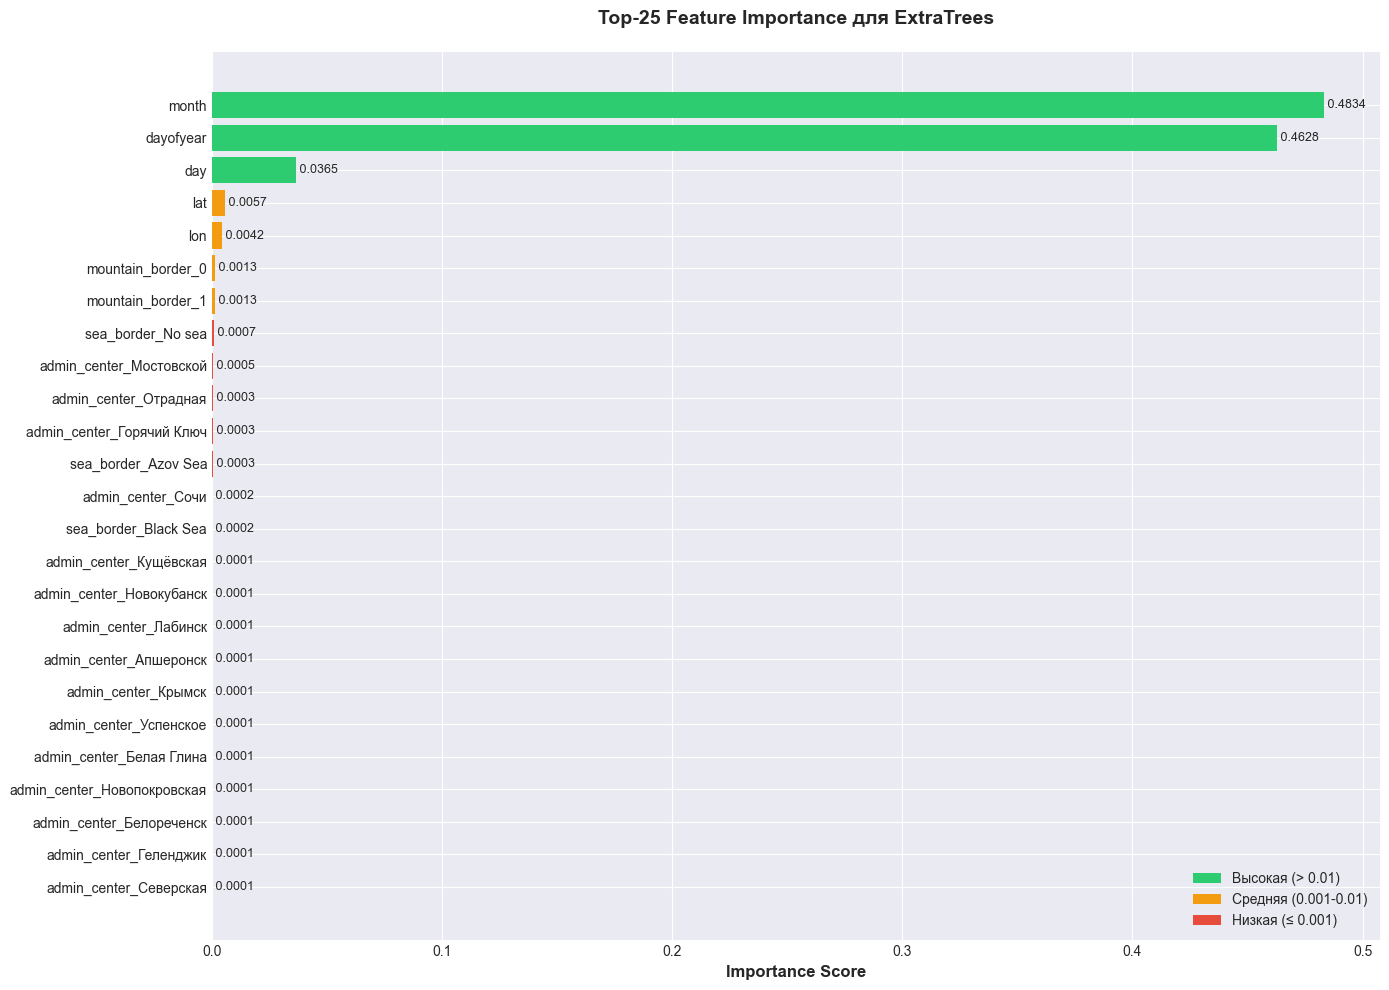

Пороговая важность: 0.001
Хорошие признаки: 7 из 55
Плохие признаки:  48 из 55


In [15]:
preprocessor_fitted = et_model_v1.named_steps['preprocessor']

raw_names = preprocessor_fitted.get_feature_names_out().tolist()

all_feature_names = [name.replace('num__', '').replace('cat__', '') for name in raw_names]

print(f"Всего признаков после preprocessing: {len(all_feature_names)}")
print(f"{all_feature_names}")


importance_df = analyze_feature_importance(et_model_v1, all_feature_names, top_n=30, verbose=True)

plot_feature_importance(importance_df, top_n=25)


threshold = IMPORTANCE_THRESHOLD
good_features = importance_df[importance_df['Importance'] >  threshold]['Feature'].tolist()
bad_features  = importance_df[importance_df['Importance'] <= threshold]['Feature'].tolist()

print(f"Пороговая важность: {threshold}")
print(f"Хорошие признаки: {len(good_features)} из {len(all_feature_names)}")
print(f"Плохие признаки:  {len(bad_features)} из {len(all_feature_names)}")



# 12. Подбор гиперпараметров

***Назначение:*** найти оптимальные гиперпараметры для ExtraTrees.

***Этап 1 — субсэмплинг:***

берётся 10% от TRAIN (frac=0.10) — ~179 тыс. строк, достаточно для оценки гиперпараметров;
y_train_sample синхронизируется с X_train_sample по индексу через .loc[X_train_sample.index].

***Этап 2 — Pipeline и сетка параметров:***

`search_pipeline` оборачивает `preprocessor` + `ExtraTreesRegressor(n_estimators=30)` — малое число деревьев только для поиска; параметры указываются с префиксом model__, чтобы RandomizedSearchCV передавал их именно в шаг model Pipeline.


***Этап 3 - поиск:***

`RandomizedSearchCV(n_iter=5, cv=2)` 
`scoring='neg_mean_absolute_error'` — оптимизируем MAE, усреднённый по всем 8 таргетам.


***Этап 4 — пересборка Pipeline:***

финальный `best_pipeline` собирается с найденными параметрами, но уже с n_estimators=50 — больше деревьев для стабильного финального результата.




In [16]:
# Берём 10% от TRAIN — достаточно для оценки гиперпараметров
SEARCH_SAMPLE = 0.10
X_train_sample = X_train.sample(frac=SEARCH_SAMPLE, random_state=RANDOM_STATE)
y_train_sample = y_train.loc[X_train_sample.index]

print(f"Полный TRAIN:   {X_train.shape[0]:,} строк")
print(f"Выборка поиска: {X_train_sample.shape[0]:,} строк ({SEARCH_SAMPLE*100:.0f}%)")


search_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ExtraTreesRegressor(
        n_estimators=30,
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

param_grid = {
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':[1, 2, 4],
}

random_search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=param_grid,
    n_iter=5,
    cv=2,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=1
)

random_search.fit(X_train_sample, y_train_sample)
best_params = random_search.best_params_
best_score  = abs(random_search.best_score_)
print("\nЛучшие гиперпараметры:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nЛучший CV MAE (на subsample): {best_score:.4f}")

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ExtraTreesRegressor(
        n_estimators=50,
        max_depth=best_params['model__max_depth'],
        min_samples_split=best_params['model__min_samples_split'],
        min_samples_leaf=best_params['model__min_samples_leaf'],
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

Полный TRAIN:   1,794,260 строк
Выборка поиска: 179,426 строк (10%)
Fitting 2 folds for each of 5 candidates, totalling 10 fits

Лучшие гиперпараметры:
  model__min_samples_split: 5
  model__min_samples_leaf: 2
  model__max_depth: 20

Лучший CV MAE (на subsample): 203360.3634


# 13. Финальнное обучение

***Назначение:*** обучить финальную модель на максимальном объёме данных (TRAIN + VAL) и оценить её на нетронутом TEST.

***Этап 1 — объединение TRAIN и VAL:***

`pd.concat([X_train, X_val], ignore_index=True)` — объединяем выборки, ignore_index=True сбрасывает индексы, чтобы не было дублей.


***Этап 2 — обучение:***

`fit(X_train_val, y_train_val)` — preprocessor обучается заново на TRAIN+VAL, модель обучается на преобразованных данных.


***Этап 3 — оценка на TEST:***

`et_model_final.predict(X_test)` — даёт финальные предсказания;
`print_metrics_per_target(y_test.values, y_test_pred, ...)` — итоговые метрики качества.


In [18]:
X_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)
print(f"X_train_val shape: {X_train_val.shape}")
print(f"y_train_val shape: {y_train_val.shape}")


et_model_final = best_pipeline
et_model_final.fit(X_train_val, y_train_val)

y_test_pred = et_model_final.predict(X_test)

metrics_test_df = print_metrics_per_target(
    y_test.values,
    y_test_pred,
    TARGET_VARIABLES,
    "ExtraTrees FINAL на TEST выборке"
)

X_train_val shape: (2093976, 8)
y_train_val shape: (2093976, 8)

МЕТРИКИ: ExtraTrees FINAL на TEST выборке


,Target,MAE,RMSE,R²,Качество
0,precipitation,2.683944e+00,4.176315e+00,-0.238732,❌ Плохо
1,temp,3.241011e+00,4.201036e+00,0.800329,✅ Хорошо
2,tmax,4.014317e+00,5.175683e+00,0.734700,✅ Хорошо
3,tmin,3.268091e+00,4.374949e+00,0.759121,✅ Хорошо
4,solar_radiation,2.066543e+06,2.739155e+06,0.713877,✅ Хорошо
5,wind_speed,1.302911e+00,1.679316e+00,0.105947,⚠️ Среднее
6,wind_direction,8.817562e+01,1.037608e+02,-0.147441,❌ Плохо
7,day_length_hours,2.753259e-02,3.486265e-02,0.999783,✅ Хорошо



                                   ИТОГОВЫЕ СТАТИСТИКИ                                    
  MAE (среднее):  258330.7425 ± 730628.1773
  RMSE (среднее): 342409.7453 ± 968431.1496
  R² (среднее):   0.4659 ± 0.4809



# 14. Сравнение результатов

***Назначение:*** сравнить качество разведочной модели на VAL и финальной модели на TEST, а также разбить таргеты по качеству предсказания.

***Этап 1 — сравнение VAL vs TEST:***

строится comparison_df из двух строк: метрики разведочной модели на VAL и финальной на TEST;
позволяет увидеть, не переобучилась ли модель (если TEST значительно хуже VAL — переобучение).


***Этап 2 — классификация таргетов:***

🟢 Хорошие (R² > 0.5) — модель объясняет больше половины дисперсии;
🟡 Средние (0 ≤ R² ≤ 0.5) — модель лучше среднего, но слабая;
🔴 Плохие (R² < 0) — модель хуже, чем просто предсказывать среднее значение.

In [19]:
comparison_data = {
    'Выборка':           ['VAL (после TRAIN)', 'TEST (финальная модель)'],
    'Количество строк':  [X_val.shape[0],       X_test.shape[0]],
    'MAE (среднее)':     [metrics_val_df['MAE'].mean(),  metrics_test_df['MAE'].mean()],
    'RMSE (среднее)':    [metrics_val_df['RMSE'].mean(), metrics_test_df['RMSE'].mean()],
    'R² (среднее)':      [metrics_val_df['R²'].mean(),   metrics_test_df['R²'].mean()],
}
comparison_df = pd.DataFrame(comparison_data)
print(f"\n{'='*90}")
print("СРАВНЕНИЕ МЕТРИК")
print(f"{'='*90}")
display(comparison_df)
print(f"{'='*90}\n")
best_targets       = metrics_test_df[metrics_test_df['R²'] > 0.5].sort_values('R²', ascending=False)
mid_targets        = metrics_test_df[(metrics_test_df['R²'] >= 0) & (metrics_test_df['R²'] <= 0.5)]
bad_targets_metrics = metrics_test_df[metrics_test_df['R²'] < 0]

print(f"🟢 ХОРОШИЕ таргеты (R² > 0.5): {len(best_targets)}")
if len(best_targets) > 0:
    display(best_targets[['Target', 'MAE', 'R²']])
else:
    print("   (нет)")

print(f"🟡 СРЕДНИЕ таргеты (0 ≤ R² ≤ 0.5): {len(mid_targets)}")
if len(mid_targets) > 0:
    display(mid_targets[['Target', 'MAE', 'R²']])
else:
    print("   (нет)")

print(f"🔴 ПЛОХИЕ таргеты (R² < 0): {len(bad_targets_metrics)}")
if len(bad_targets_metrics) > 0:
    display(bad_targets_metrics[['Target', 'MAE', 'R²']])
else:
    print("   (нет)")



СРАВНЕНИЕ МЕТРИК


,Выборка,Количество строк,MAE (среднее),RMSE (среднее),R² (среднее)
0,VAL (после TRAIN),299716,270139.981665,371349.977392,0.332025
1,TEST (финальная модель),293313,258330.742462,342409.745282,0.465948



🟢 ХОРОШИЕ таргеты (R² > 0.5): 5


,Target,MAE,R²
7,day_length_hours,2.753259e-02,0.999783
1,temp,3.241011e+00,0.800329
3,tmin,3.268091e+00,0.759121
2,tmax,4.014317e+00,0.734700
4,solar_radiation,2.066543e+06,0.713877


🟡 СРЕДНИЕ таргеты (0 ≤ R² ≤ 0.5): 1


,Target,MAE,R²
5,wind_speed,1.302911,0.105947


🔴 ПЛОХИЕ таргеты (R² < 0): 2


,Target,MAE,R²
0,precipitation,2.683944,-0.238732
6,wind_direction,88.175618,-0.147441


# 15. Сохранение модели

In [20]:
model_path = 'artifacts/model.pkl'
joblib.dump({
    'model':                et_model_final,
    'targets':              TARGET_VARIABLES,
    'features_numeric':     NUMERIC_FEATURES,
    'features_categorical': CATEGORICAL_FEATURES,
    'all_features':         all_feature_names,
    'best_params':          best_params,
    'test_metrics':         metrics_test_df.to_dict(),
    'config': {
        'TRAIN_YEARS':      TRAIN_YEARS,
        'VAL_YEARS':        VAL_YEARS,
        'TEST_YEARS':       TEST_YEARS,
        'RANDOM_STATE':     RANDOM_STATE,
    }
}, model_path)
print(f"Модель сохранена: {model_path}")


Модель сохранена: model.pkl


# 16. Финальная сводка

In [23]:
summary = f"""
КОНФИГУРАЦИЯ:
  • Целевые переменные: {len(TARGET_VARIABLES)} ({', '.join(TARGET_VARIABLES)})
  • Признаки числовые: {len(NUMERIC_FEATURES)} ({', '.join(NUMERIC_FEATURES)})
  • Признаки категориальные: {len(CATEGORICAL_FEATURES)} ({', '.join(CATEGORICAL_FEATURES)})
  • Признаков после preprocessing: {len(all_feature_names)}

РАЗДЕЛЕНИЕ ДАННЫХ:
  • TRAIN ({', '.join(map(str, TRAIN_YEARS))}): {X_train.shape[0]} строк
  • VAL   ({', '.join(map(str, VAL_YEARS))}): {X_val.shape[0]} строк
  • TEST  ({', '.join(map(str, TEST_YEARS))}): {X_test.shape[0]} строк

ФИНАЛЬНЫЕ МЕТРИКИ (TEST):
  • MAE (среднее):  {metrics_test_df['MAE'].mean():.4f}
  • RMSE (среднее): {metrics_test_df['RMSE'].mean():.4f}
  • R² (среднее):   {metrics_test_df['R²'].mean():.4f}

АНАЛИЗ ПРИЗНАКОВ:
  • Хорошие признаки (> 0.001): {len(good_features)}
  • Плохие признаки (≤ 0.001): {len(bad_features)}

АНАЛИЗ ЦЕЛЕВЫХ ПЕРЕМЕННЫХ:
  • Хорошие (R² > 0.5): {len(best_targets)}
  • Средние (0 ≤ R² ≤ 0.5): {len(mid_targets)}
  • Плохие (R² < 0): {len(bad_targets_metrics)}

"""
print(summary)


КОНФИГУРАЦИЯ:
  • Целевые переменные: 8 (precipitation, temp, tmax, tmin, solar_radiation, wind_speed, wind_direction, day_length_hours)
  • Признаки числовые: 5 (lat, lon, month, day, dayofyear)
  • Признаки категориальные: 3 (sea_border, mountain_border, admin_center)
  • Признаков после preprocessing: 55

РАЗДЕЛЕНИЕ ДАННЫХ:
  • TRAIN (2018, 2019, 2020, 2021, 2022, 2023): 1794260 строк
  • VAL   (2024): 299716 строк
  • TEST  (2025): 293313 строк

ФИНАЛЬНЫЕ МЕТРИКИ (TEST):
  • MAE (среднее):  258330.7425
  • RMSE (среднее): 342409.7453
  • R² (среднее):   0.4659

АНАЛИЗ ПРИЗНАКОВ:
  • Хорошие признаки (> 0.001): 7
  • Плохие признаки (≤ 0.001): 48

АНАЛИЗ ЦЕЛЕВЫХ ПЕРЕМЕННЫХ:
  • Хорошие (R² > 0.5): 5
  • Средние (0 ≤ R² ≤ 0.5): 1
  • Плохие (R² < 0): 2


